2
a
Load the Iris dataset.
i) Explore the dataset by printing the first 7 rows including feature names and the target variable.
ii)Display the number of samples and features in the dataset.
iii) Split the dataset into training (70%) and testing (30%) sets.
b
Use the same dataset to perform KMeans Clustering with 3 clusters. Predict the cluster labels and create a scatter plot of the first two features colored by the predicted cluster labels.
NB: Don't use the inbuilt function for KMeans Clustering in sklearn
c
Perform agglomerative hierarchical clustering to cluster the data into 3 clusters. Fit the model and predict the cluster labels. Create a dendrogram to visualize the hierarchical relationships between the clusters.
d
Calculate and print the silhouette score for each clustering result. Compare the results.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, dendrogram

In [7]:
#2.a

iris = load_iris()

#i
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

print(df.head(7))

#ii
r,c = df.shape
print("No. of samples : ", r)
print("No. of features : ", c-1)

#iii
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  
5        0  
6        0  
No. of samples :  150
No. of features :  4


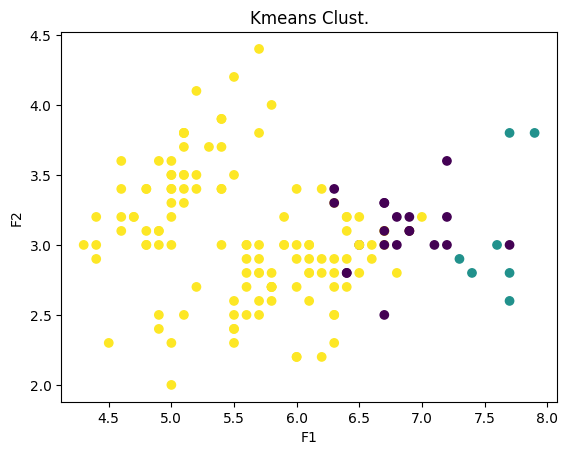

In [13]:
#2.b

def kM(X, k=3, iters=100):
  centroids = X[np.random.choice(len(X), k, replace=False)]

  for _ in range(iters):
    clusters = [[] for _ in range(k)]
    for point in X:
        distances = [np.linalg.norm(point-c) for c in centroids]
        cluster_index = np.argmin(distances)
        clusters[cluster_index].append(point)

    new_centroids = []
    for cluster in clusters :
      new_centroids.append(np.mean(cluster,axis=0))
    new_centroids = np.array(new_centroids)

    if np.all(centroids== new_centroids):
      break
  labels = []
  for point in X:
    distances = [np.linalg.norm(point-c)for c in centroids]
    labels.append(np.argmin(distances))
  return np.array(labels), centroids

labels_kmeans, centroids = kM(iris.data, k=3)

plt.scatter(iris.data[:,0], iris.data[:,1], c=labels_kmeans)
plt.xlabel("F1")
plt.ylabel("F2")
plt.title("Kmeans Clust.")
plt.show()

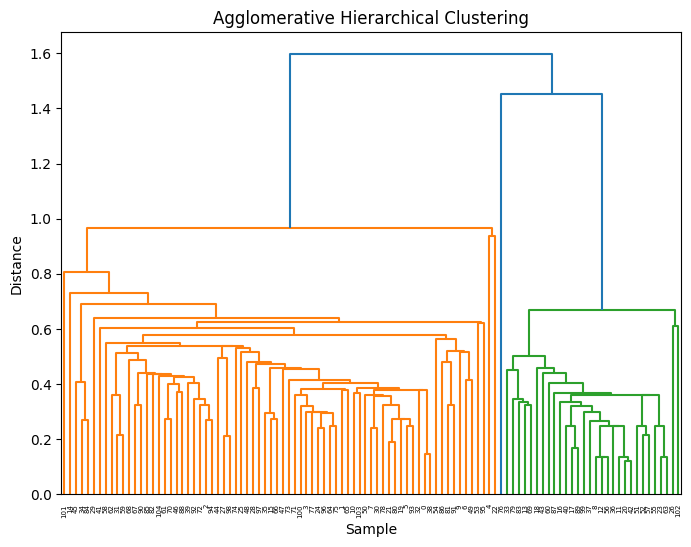

In [17]:
#2.c
X_train_agg, X_test_agg = train_test_split(X, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

agg = AgglomerativeClustering(n_clusters=3)
cluster_labels = agg.fit_predict(X_train)

plt.figure(figsize=(8,6))
linked = linkage(X_scaled)
dendrogram(linked)
plt.xlabel("Sample")
plt.ylabel("Distance")
plt.title("Agglomerative Hierarchical Clustering")
plt.show()

In [19]:
print("kMeans = ",silhouette_score(X, labels_kmeans))
print("Agg = ", silhouette_score(X_scaled, cluster_labels))

kMeans =  0.16684963742656841
Agg =  0.4637585446055316
